## NATALIA VALENTINA VALDA IBÁÑEZ

## EJERCICIO 1


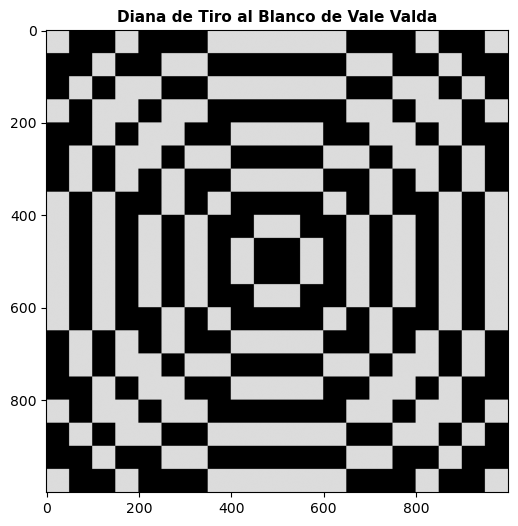

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## DIANA DE TIRO AL BLANCO 
casilla = 50
n_casilllas = 20
tam = casilla * n_casilllas

diana = np.full((tam, tam), 220, dtype=np.uint8)
centro = n_casilllas // 2

for fila in range(n_casilllas):
    for col in range(n_casilllas):
        distancia = np.sqrt((fila - centro + 0.5)**2 + (col - centro + 0.5)**2)

        if int (distancia) % 2 == 0:
            y1,y2 = fila * casilla, (fila + 1) * casilla
            x1,x2 = col * casilla, (col + 1) * casilla
            diana[y1:y2, x1:x2] = 0


plt.figure(figsize=(6, 6))
plt.imshow(diana, cmap='gray', vmin=0, vmax=255)
plt.title('Diana de Tiro al Blanco de Vale Valda', fontweight='bold', fontsize=11)
plt.show()


## EJERCICIO 2


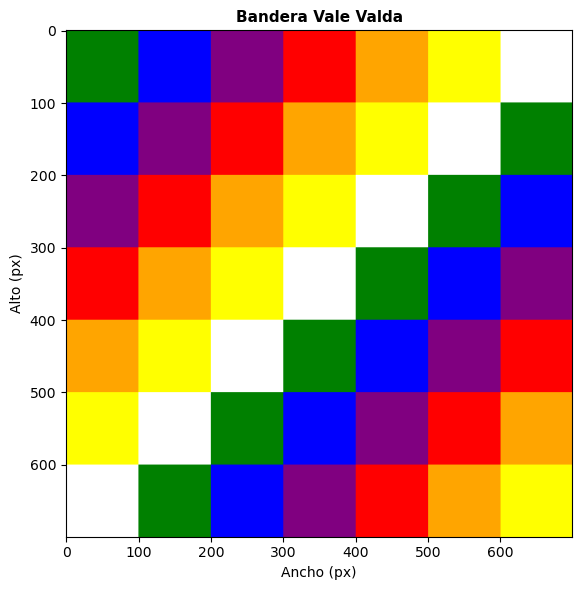

Bandera generada: (700, 700, 3)
Guardado como 'bandera.png'


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

casilla = 100  
n = 7
tam = casilla * n

colores = [
    (0, 128, 0),    # verde
    (0, 0, 255),    # azul
    (128, 0, 128),  # morado
    (255, 0, 0),    # rojo
    (255, 165, 0),  # naranja
    (255, 255, 0),  # amarillo
    (255, 255, 255), #blanco 
    (0, 128, 0),    # verde
    (0, 0, 255),    # azul
    (128, 0, 128),  # morado
    (255, 0, 0),    # rojo
    (255, 165, 0),  # naranja
    (255, 255, 0),  # amarillo

]
bandera = np.zeros((tam, tam,3), dtype=np.uint8)

for fila in range(n):
    for col in range(n):
        idx = (fila + col) % n
        y1, y2 = fila * casilla, (fila + 1) * casilla
        x1, x2 = col * casilla, (col + 1) * casilla
        bandera[y1:y2, x1:x2] = colores[idx]
        
cv2.imwrite('bandera.png', bandera)

plt.figure(figsize=(6, 6))
plt.imshow(bandera, cmap='gray', vmin=0, vmax=255)
plt.title(f'Bandera Vale Valda',
          fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Bandera generada: {bandera.shape}")
print("Guardado como 'bandera.png'")

## EJERCICIO 3

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random


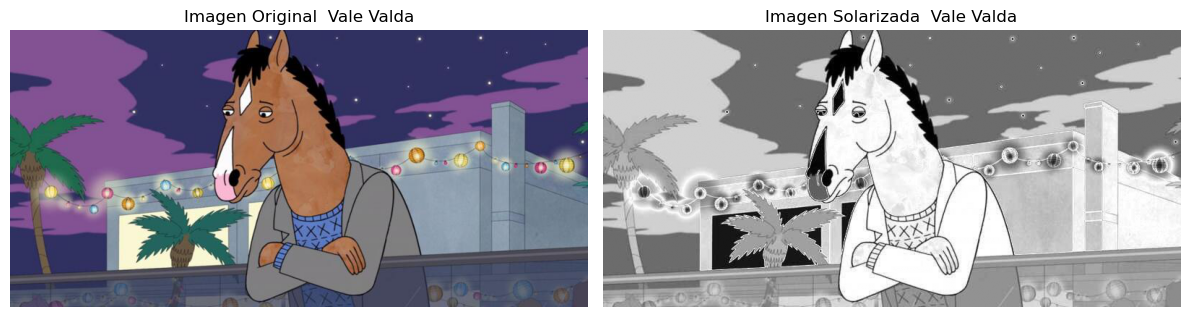

In [45]:
def solarizar(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol.astype(np.uint8)

imagen = cv2.imread('imagen1.jpg')
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

umbral = 127
img_fin = solarizar(img_gray, umbral)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Imagen Original  Vale Valda")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Imagen Solarizada  Vale Valda")
plt.imshow(img_fin, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

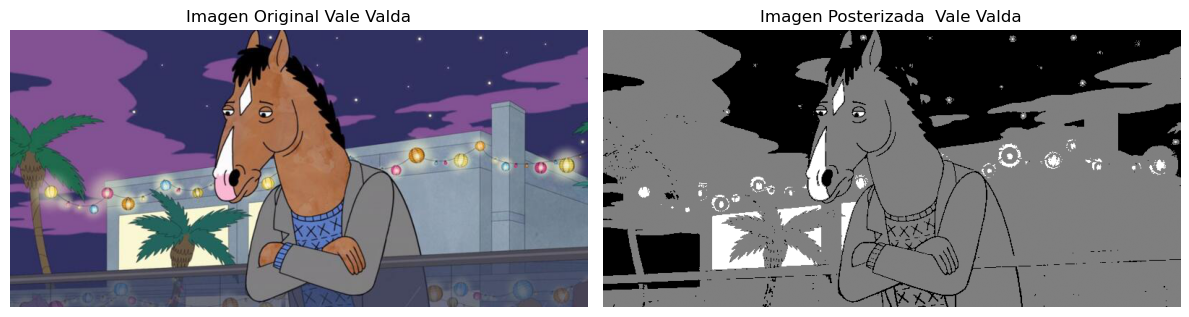

In [44]:
def posterizar(imagen,niveles):
    factor_escala=255/niveles
    img_pos=np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

imagen = cv2.imread('imagen1.jpg')
img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
nvl=2
img_fin=posterizar(img_gray,nvl)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Imagen Original Vale Valda")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Imagen Posterizada  Vale Valda")
plt.imshow(img_fin, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

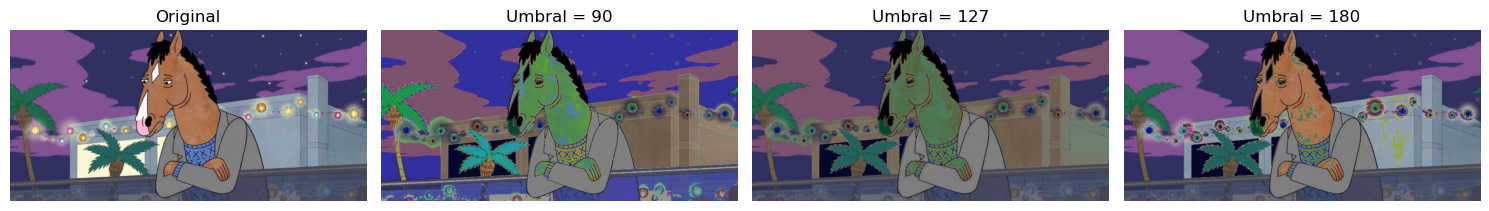

In [ ]:
def solarizacion_color(imagen, umbral):
    img_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return img_sol

imagen = cv2.imread('imagen1.jpg')

if imagen is None:
    print("Error: No se pudo cargar la imagen 'imagen.jpg'")
else:
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    umbrales = [90, 127, 180]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(imagen_rgb)
    plt.title('Original')
    plt.axis('off')
    
    for i, umbral in enumerate(umbrales, 2):
        img_sol = solarizacion_color(imagen_rgb, umbral)
        
        plt.subplot(1, 4, i)
        plt.imshow(img_sol)
        plt.title(f'Umbral = {umbral}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

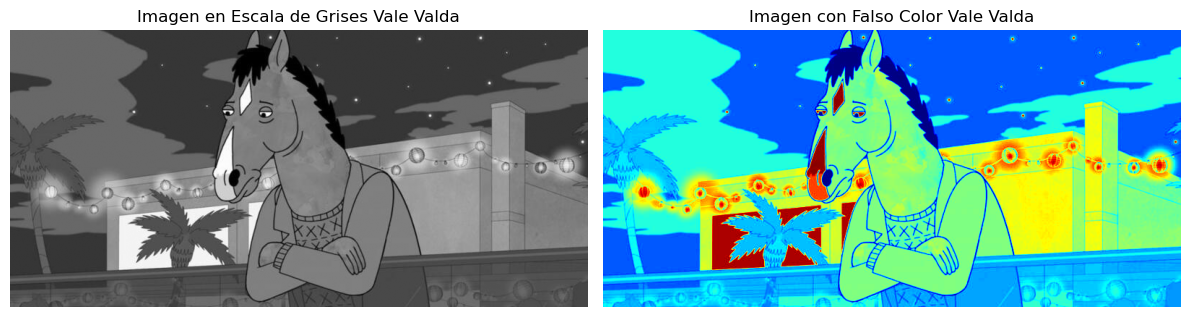

In [49]:
def falso_color(img_gray):

    escal_img = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)

    escal_img = escal_img.astype(np.uint8)

    falso_img = cv2.applyColorMap(escal_img, cv2.COLORMAP_JET)

    falso_img_rgb = cv2.cvtColor(falso_img, cv2.COLOR_BGR2RGB)
    return falso_img_rgb


imagen = cv2.imread('imagen1.jpg')

if imagen is None:
    print("Error: No se pudo cargar la imagen 'imagen1.jpg'")
    print("Verifica que el archivo esté en la misma carpeta que tu notebook")
else:

    img_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    

    img_falso_color = falso_color(img_gray)
    
  
    plt.figure(figsize=(12, 6))
    

    plt.subplot(121)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Imagen en Escala de Grises Vale Valda')
    plt.axis('off')
    
    plt.subplot(122)
    plt.imshow(img_falso_color)
    plt.title('Imagen con Falso Color Vale Valda')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

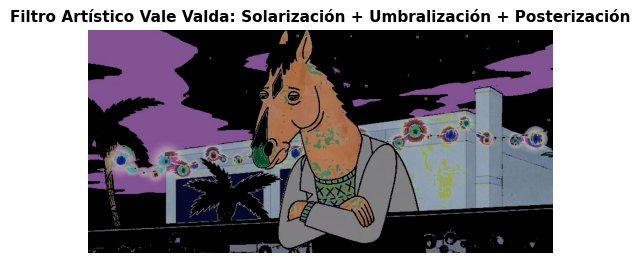

In [43]:
_, img_umbral = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
img_umbral_3ch = cv2.cvtColor(img_umbral, cv2.COLOR_GRAY2RGB)

filtro_nuevo = cv2.bitwise_and(img_sol, img_umbral_3ch)

cv2.imwrite('filtro_artistico.png', cv2.cvtColor(filtro_nuevo, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(6,6))
plt.imshow(filtro_nuevo)
plt.title('Filtro Artístico Vale Valda: Solarización + Umbralización + Posterización', fontweight='bold', fontsize=11)
plt.axis('off')
plt.show()

## EJERCICIO 4

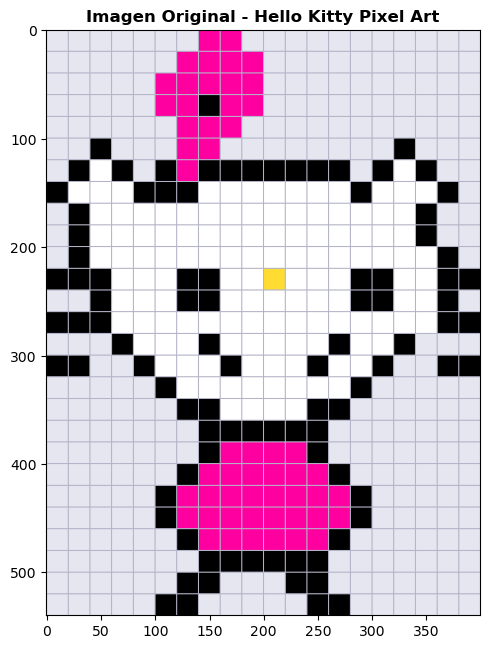

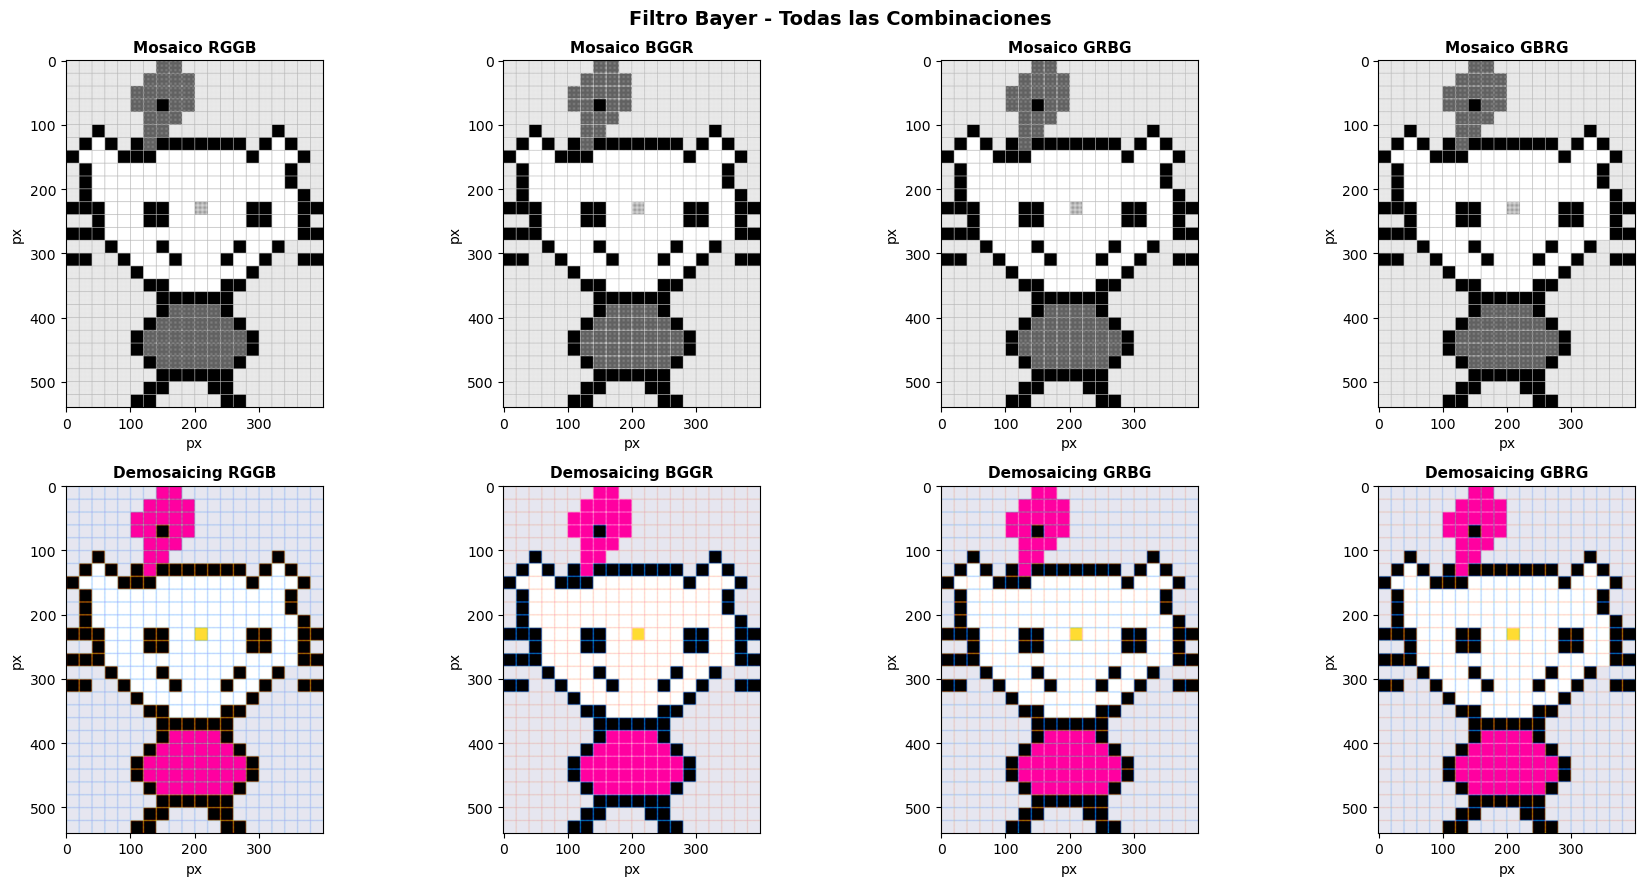

Imágenes guardadas: imagen original + 4 mosaicos + 4 reconstrucciones


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

img_bgr = cv2.imread('imagen.jpg')
if img_bgr is None:
    print("Error: No se pudo cargar la imagen. Verifica el nombre del archivo.")
else:
    imagen_original = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    def aplicar_bayer(img_rgb, patron):
        """Simula el mosaico Bayer sobre una imagen RGB"""
        alto, ancho = img_rgb.shape[:2]
        alto = (alto // 2) * 2
        ancho = (ancho // 2) * 2
        img_rgb = img_rgb[:alto, :ancho]
        
        R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
        bayer = np.zeros((alto, ancho), dtype=np.uint8)
        
        y_par = np.arange(0, alto, 2)
        y_impar = np.arange(1, alto, 2)
        x_par = np.arange(0, ancho, 2)
        x_impar = np.arange(1, ancho, 2)
        
        if patron == 'RGGB':
            bayer[np.ix_(y_par, x_par)] = R[np.ix_(y_par, x_par)]
            bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
            bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
            bayer[np.ix_(y_impar, x_impar)] = B[np.ix_(y_impar, x_impar)]
        elif patron == 'BGGR':
            bayer[np.ix_(y_par, x_par)] = B[np.ix_(y_par, x_par)]
            bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
            bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
            bayer[np.ix_(y_impar, x_impar)] = R[np.ix_(y_impar, x_impar)]
        elif patron == 'GRBG':
            bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
            bayer[np.ix_(y_par, x_impar)] = R[np.ix_(y_par, x_impar)]
            bayer[np.ix_(y_impar, x_par)] = B[np.ix_(y_impar, x_par)]
            bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
        elif patron == 'GBRG':
            bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
            bayer[np.ix_(y_par, x_impar)] = B[np.ix_(y_par, x_impar)]
            bayer[np.ix_(y_impar, x_par)] = R[np.ix_(y_impar, x_par)]
            bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
        
        return bayer
import numpy as np
import matplotlib.pyplot as plt
import cv2


paleta = {
    0: (230, 230, 240),   # fondo (gris claro / grid)
    1: (0, 0, 0),         # negro (contorno)
    2: (255, 255, 255),   # blanco (cuerpo)
    3: (255, 0, 160),     # rosa/magenta (lazo y vestido)
    4: (255, 220, 50),    # amarillo (nariz)
}


hk = np.array([
    # Lazo (arriba)
    [0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0],  # 0
    [0,0,0,0,0,0,3,3,3,3,0,0,0,0,0,0,0,0,0,0],  # 1
    [0,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0],  # 2
    [0,0,0,0,0,3,3,1,3,3,0,0,0,0,0,0,0,0,0,0],  # 3 nudo del lazo
    [0,0,0,0,0,0,3,3,3,0,0,0,0,0,0,0,0,0,0,0],  # 4 base lazo
    # Orejas + cabeza
    [0,0,1,0,0,0,3,3,0,0,0,0,0,0,0,0,1,0,0,0],  # 5 puntas orejas
    [0,1,2,1,0,1,3,1,1,1,1,1,1,1,0,1,2,1,0,0],  # 6 lados orejas
    [1,2,2,2,1,1,1,2,2,2,2,2,2,2,1,2,2,2,1,0],  # 7 orejas + cabeza
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,0],  # 8 cabeza
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,0],  # 9
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0],  # 10
    # Ojos + nariz + bigotes
    [1,1,1,2,2,2,1,1,2,2,4,2,2,2,1,1,2,2,1,1],  # 11 ojos+nariz+bigotes
    [0,0,1,2,2,2,1,1,2,2,2,2,2,2,1,1,2,2,1,0],  # 12 ojos
    [1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1],  # 13 bigotes
    # Boca
    [0,0,0,1,2,2,2,1,2,2,2,2,2,1,2,2,1,0,0,0],  # 14 boca
    [1,1,0,0,1,2,2,2,1,2,2,2,1,2,2,1,0,0,1,1],  # 15 bigotes
    [0,0,0,0,0,1,2,2,2,2,2,2,2,2,1,0,0,0,0,0],  # 16
    [0,0,0,0,0,0,1,1,2,2,2,2,1,1,0,0,0,0,0,0],  # 17
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],  # 18 barbilla
    # Vestido
    [0,0,0,0,0,0,0,1,3,3,3,3,1,0,0,0,0,0,0,0],  # 19
    [0,0,0,0,0,0,1,3,3,3,3,3,3,1,0,0,0,0,0,0],  # 20
    [0,0,0,0,0,1,3,3,3,3,3,3,3,3,1,0,0,0,0,0],  # 21
    [0,0,0,0,0,1,3,3,3,3,3,3,3,3,1,0,0,0,0,0],  # 22
    [0,0,0,0,0,0,1,3,3,3,3,3,3,1,0,0,0,0,0,0],  # 23
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],  # 24
    # Pies
    [0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0],  # 25
    [0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0],  # 26
], dtype=np.uint8)


escala = 20
alto_px, ancho_px = hk.shape
tam_alto = alto_px * escala
tam_ancho = ancho_px * escala

# Crear imagen RGB
imagen_arte = np.zeros((tam_alto, tam_ancho, 3), dtype=np.uint8)

for y in range(alto_px):
    for x in range(ancho_px):
        color = paleta[hk[y, x]]
        y1, y2 = y * escala, (y + 1) * escala
        x1, x2 = x * escala, (x + 1) * escala
        imagen_arte[y1:y2, x1:x2] = color

for y in range(0, tam_alto, escala):
    imagen_arte[y, :] = (180, 180, 200)
for x in range(0, tam_ancho, escala):
    imagen_arte[:, x] = (180, 180, 200)

imagen_arte_bgr = cv2.cvtColor(imagen_arte, cv2.COLOR_RGB2BGR)
cv2.imwrite('ej6_imagen_hellokitty.png', imagen_arte_bgr)

plt.figure(figsize=(5, 7))
plt.imshow(imagen_arte)
plt.title('Imagen Original - Hello Kitty Pixel Art', fontweight='bold', fontsize=12)
plt.axis('on')
plt.tight_layout()
plt.show()

alto, ancho = imagen_arte.shape[:2]
R = imagen_arte[:, :, 0]
G = imagen_arte[:, :, 1]
B = imagen_arte[:, :, 2]


def aplicar_bayer(img_rgb, patron):
    """Simula el mosaico Bayer sobre una imagen RGB"""
    alto, ancho = img_rgb.shape[:2]
    R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    bayer = np.zeros((alto, ancho), dtype=np.uint8)
    
    y_par = np.arange(0, alto, 2)
    y_impar = np.arange(1, alto, 2)
    x_par = np.arange(0, ancho, 2)
    x_impar = np.arange(1, ancho, 2)
    
    if patron == 'RGGB':
        bayer[np.ix_(y_par, x_par)] = R[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = B[np.ix_(y_impar, x_impar)]
    elif patron == 'BGGR':
        bayer[np.ix_(y_par, x_par)] = B[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = R[np.ix_(y_impar, x_impar)]
    elif patron == 'GRBG':
        bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = R[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = B[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
    elif patron == 'GBRG':
        bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = B[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = R[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
    
    return bayer

bayer_configs = [
    ('RGGB', cv2.COLOR_BAYER_BG2BGR),
    ('BGGR', cv2.COLOR_BAYER_RG2BGR),
    ('GRBG', cv2.COLOR_BAYER_GB2BGR),
    ('GBRG', cv2.COLOR_BAYER_GR2BGR),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (patron, demosaic_code) in enumerate(bayer_configs):
    bayer_img = aplicar_bayer(imagen_arte, patron)
    
    reconstruida = cv2.cvtColor(bayer_img, demosaic_code)
    reconstruida_rgb = cv2.cvtColor(reconstruida, cv2.COLOR_BGR2RGB)
    
    cv2.imwrite(f'ej6_bayer_{patron}_mosaico.png', bayer_img)
    cv2.imwrite(f'ej6_bayer_{patron}_reconstruida.png', reconstruida)
 
    axes[0, i].imshow(bayer_img, cmap='gray')
    axes[0, i].set_title(f'Mosaico {patron}', fontweight='bold', fontsize=11)
    
    axes[1, i].imshow(reconstruida_rgb)
    axes[1, i].set_title(f'Demosaicing {patron}', fontweight='bold', fontsize=11)

for ax in axes.flatten():
    ax.set_xlabel('px')
    ax.set_ylabel('px')

fig.suptitle('Filtro Bayer - Todas las Combinaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Imágenes guardadas: imagen original + {len(bayer_configs)} mosaicos + {len(bayer_configs)} reconstrucciones")